# Imports and Defs

In [1]:
import time as _time

import numpy as _np
import matplotlib.pyplot as plt

from mathphys.functions import load

from siriuspy.oscilloscope import Keysight, Scopes, ScopeSignals
from siriuspy.oscilloscope import Waveform, WaveformUtils

def plot_waveforms(wfms):
    for chan in wfms:
        plt.plot(1e6*wfms[chan][0], 1e3*wfms[chan][1], label=chan)
    plt.xlabel('time [µs]')
    plt.ylabel('Voltage [mV]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Test Scopes and ScopeSignals

In [2]:
print(ScopeSignals.LI_ICT1)

print(ScopeSignals.get_scopesignal('LI_ICT1'))
print(ScopeSignals.get_scopesignal(ScopeSignals.LI_ICT1))

print(ScopeSignals.get_channel(ScopeSignals.LI_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.LI_ICT2))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT1))
print(ScopeSignals.get_channel(ScopeSignals.TB_ICT2))

('LI_ICT1', 'LI_DI_ICT', 'channel1')
('LI_ICT1', 'LI_DI_ICT', 'channel1')
('LI_ICT1', 'LI_DI_ICT', 'channel1')
channel1
channel2
channel3
channel4


In [3]:
print(Scopes.LI_DI_ICT)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [4]:
scope = Scopes.get_scope(ScopeSignals.LI_ICT1)
print(scope)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [5]:
print(Scopes.get_scope(ScopeSignals.LI_MODLTR1))

scopename      : LI_PU_MODLTR
ipaddr         : 10.128.150.150
hostname       : KEYSIGH-QQI8MNR.abtlus.org.br
port           : 5025
channel1       : LI_MODLTR1
channel2       : None
channel3       : LI_MODLTR2
channel4       : None
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


# Test Keysight

In [6]:
scope = Scopes.TS_PU_EJEBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_PU_MODLTR; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TS_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FCT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.AS_DI_FPM; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.TB_PU_INJBO; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.LI_DI_ICT; print(f'{scope.scopename:<20s} : {scope.get_identification()}')
scope = Scopes.SI_PU_INJSI; print(f'{scope.scopename:<20s} : {scope.get_identification()}')

TS_PU_EJEBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500104,06.75.00010
LI_PU_MODLTR         : KEYSIGHT TECHNOLOGIES,DSOS054A,MY55300112,06.74.01819
TS_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500106,06.75.00010
AS_DI_FCT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500107,06.74.00204
AS_DI_FPM            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500108,06.10.00804
TB_PU_INJBO          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500109,06.75.00010
LI_DI_ICT            : KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101
SI_PU_INJSI          : KEYSIGHT TECHNOLOGIES,DSOS054A,MY57500111,06.75.00010


In [7]:
k = Scopes.LI_DI_ICT
print(k)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [8]:
t0 = _time.time()
idn = k.get_identification()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 449.000 ms


In [9]:
idn

'KEYSIGHT TECHNOLOGIES,DSOS104A,MY57500110,06.74.01101'

In [10]:
t0 = _time.time()
k.channel_select('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 0.552 ms


In [11]:
t0 = _time.time()
k.scales_read('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 503.434 ms


In [12]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26754e-06, 0.13571)}


In [13]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 838.872 ms


In [14]:
print(k.channels_scales)

{'channel1': (2.5e-11, 5.26754e-06, 0.13571), 'channel2': (2.5e-11, 5.27005e-06, 0.0221122), 'channel3': (2.5e-11, 5.27024e-06, 0.0053124), 'channel4': (2.5e-11, 6.58688e-06, 0.0216396)}


In [15]:
t0 = _time.time()
k.wfm_config()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 0.672 ms


In [16]:
t0 = _time.time()
k.wfm_read_raw()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 435.454 ms


In [17]:
t0 = _time.time()
datax, datay = k.wfm_read_channel('channel1')
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 960.373 ms


In [18]:
t0 = _time.time()
data = k.wfm_read()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 714.955 ms


In [19]:
k.meas_read()

{'Charge-TB-ICT2': {'CURR': 8.292e-10,
  'MEAN': 1.0,
  'MIN': 8.292e-10,
  'MAX': 8.292e-10,
  'RANGE': 8.292e-10,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-TB-ICT1': {'CURR': 2.6839e-09,
  'MEAN': 0.0,
  'MIN': 2.6839e-09,
  'MAX': 2.6839e-09,
  'RANGE': 2.6839e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT2': {'CURR': 1.27075e-09,
  'MEAN': 0.0,
  'MIN': 1.27075e-09,
  'MAX': 1.27075e-09,
  'RANGE': 1.27075e-09,
  'STD': 0.0,
  'COUNT': 1.0},
 'Charge-LI-ICT1': {'CURR': 3.0728e-10,
  'MEAN': 0.0,
  'MIN': 3.0728e-10,
  'MAX': 3.0728e-10,
  'RANGE': 3.0728e-10,
  'STD': 0.0,
  'COUNT': 1.0}}

In [20]:
print(data)

{'LI_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.00317869, 0.00317869, 0.00313655, ..., 0.00292585, 0.00288371,
       0.00288371])), 'LI_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([0.013385  , 0.013385  , 0.013385  , ..., 0.01262611, 0.01258395,
       0.01262611])), 'TB_ICT1': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([-0.02740525, -0.02736309, -0.02736309, ..., -0.02651985,
       -0.02647769, -0.02651985])), 'TB_ICT2': (array([0.00000e+00, 2.50000e-11, 5.00000e-11, ..., 5.00150e-07,
       5.00175e-07, 5.00200e-07]), array([-0.02820991, -0.0282626 , -0.0282626 , ..., -0.02857877,
       -0.02852608, -0.02857877]))}


In [21]:
t0 = _time.time()
k.scales_update_all()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 866.459 ms


In [22]:
for _ in range(10):
    t0 = _time.time()
    meas, wfms = k.acquire(acq_meas=True, acq_wfms=True)
    t1 = _time.time()
    print(f'time: {1e3*(t1-t0):.3f} ms')

time: 815.039 ms
time: 690.880 ms
time: 1023.577 ms
time: 1261.646 ms
time: 1036.324 ms
time: 1502.671 ms
time: 677.826 ms
time: 1317.364 ms
time: 1490.064 ms
time: 1622.150 ms


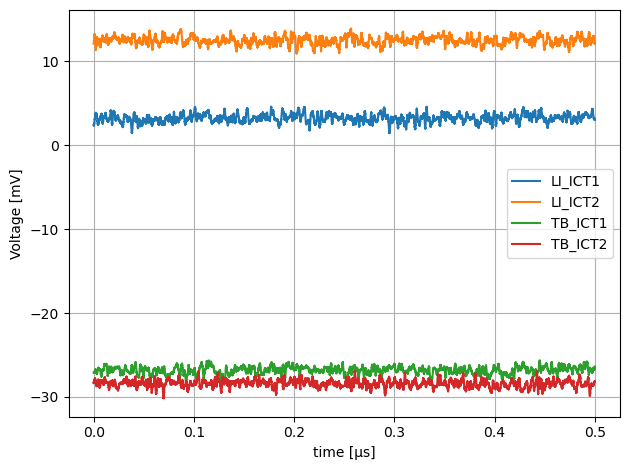

In [23]:
plot_waveforms(wfms)

In [24]:
t0 = _time.time()
dr = k.setup_fetch()
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 265.155 ms


In [25]:
t0 = _time.time()
drc = k.setup_compress(dr)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 323.330 ms


In [26]:
t0 = _time.time()
drdc = k.setup_decompress(drc)
t1 = _time.time()
print(f'time: {1e3*(t1-t0):.3f} ms')

time: 4.864 ms


In [27]:
len(dr), len(drc), len(drdc)

(2438265, 67224, 2438265)

In [13]:
# k.setup_apply(drdc)

# Test Waveform

In [28]:
nrpts = 10000

tim_gauss, wfm_gauss = WaveformUtils.gen_gauss(nrpts=nrpts, sigma=0.1)
tim_gauss2, wfm_gauss2 = WaveformUtils.gen_gauss(nrpts=nrpts, sigma=0.05, avg=0.7)
tim_sin, wfm_sin = WaveformUtils.gen_sine(nrpts=nrpts, period=1/4, amplitude=0.05)
tim_cos, wfm_cos = WaveformUtils.gen_sine(nrpts=nrpts, period=1/4, amplitude=0.05, phase=_np.pi/2)
tim_uni, wfm_uni = WaveformUtils.gen_uniform(nrpts, amplitude=0.5)

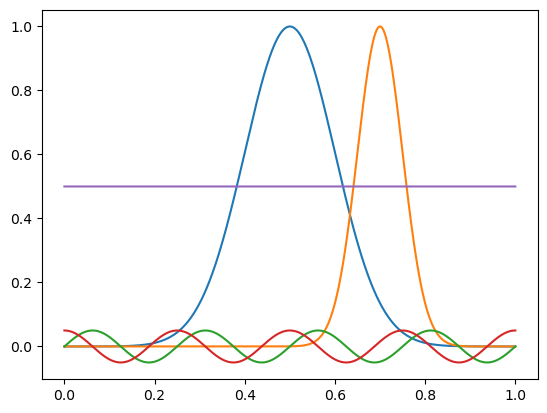

In [29]:
plt.plot(tim_gauss, wfm_gauss)
plt.plot(tim_gauss2, wfm_gauss2)
plt.plot(tim_sin, wfm_sin)
plt.plot(tim_cos, wfm_cos)
plt.plot(tim_uni, wfm_uni)
plt.show()

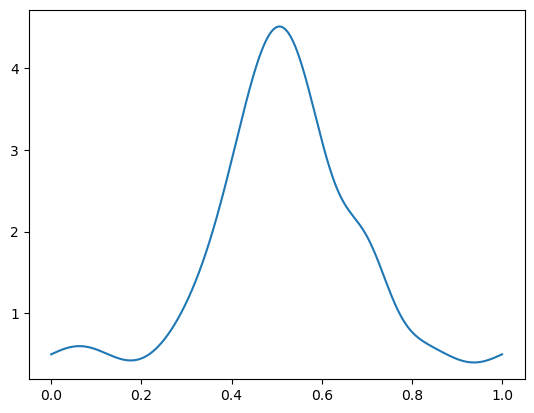

In [30]:
wfms = (wfm_uni, wfm_sin, wfm_cos, wfm_gauss, wfm_gauss2)
weights = (1, 2, 0, 4, 1)

tim_tot = tim_uni
wfm_tot = 0 * wfm_uni
for w, wfm in zip(weights, wfms):
    wfm_tot += w  *wfm

wfm = Waveform(tim_tot, wfm_tot)
plt.plot(wfm.tim, wfm.wfm)
plt.show()

In [31]:
coeffs, residues, rank, s = wfm.fit_linear_coeffs(wfms)

In [32]:
coeffs

array([1.00000000e+00, 2.00000000e+00, 3.70616217e-15, 4.00000000e+00,
       1.00000000e+00])

# Generate Pulse Waveform and Sin/Cos

In [2]:
def fit_signal(wfm_sig, period, wfm_pul=None):
    nrpts = len(wfm_sig.wfm)
    tim_init, tim_final = wfm_sig.tim[0], wfm_sig.tim[-1]
    wfm_ = WaveformUtils.gen_uniform(nrpts, tim_init=tim_init, tim_final=tim_final)
    wfm_uni = Waveform(*wfm_)
    wfm_ = WaveformUtils.gen_sine(nrpts, period=period, tim_init=tim_init, tim_final=tim_final, phase=0)
    wfm_sin = Waveform(*wfm_)
    wfm_ = WaveformUtils.gen_sine(nrpts, period=period, tim_init=tim_init, tim_final=tim_final, phase=_np.pi/2)
    wfm_cos = Waveform(*wfm_)
    if wfm_pul:
        wfms = [wfm_pul, wfm_uni, wfm_sin, wfm_cos]
    else:
        wfms = [wfm_uni, wfm_sin, wfm_cos]
    coeffs, residues, wfm_fit, *_ = wfm_sig.fit_linear_coeffs(wfms)
    nresidues = _np.sqrt(residues / len(wfm_sig.wfm))
    return coeffs, residues, wfm_fit, wfms

## Read from previous data

In [34]:
ls /home/ximenes.resende/shared/screens-iocs/data_by_day/ | grep scope

2026-07-03-AS_scope_li_tb_ict_tests/
2026-07-17-AS_scope_li_tb_ict_tests/
2026-07-20-AS_scope_li_tb_ict_tests/
2026-07-27-AS_scope_li_tb_ict_tests/
2026-08-03-AS_scope_li_tb_ict_tests/
2026-08-10-AS_scope_li_tb_ict_tests/
2026-08-11-AS_scope_li_tb_ict_tests/
2026-08-18-AS_scope_li_tb_ict_tests/
2026-08-24-AS_scope_li_tb_ict_tests/
2026-09-12-AS_scope_li_tb_ict_tests/


In [35]:
ls /home/ximenes.resende/shared/screens-iocs/data_by_day/2026-08-11-AS_scope_li_tb_ict_tests/

acquisition.ipynb  test_li_tb_scope_no_split_tb_50_ohm_01.pickle
analysis.ipynb     test_li_tb_scope_split_tb_1M_ohm_01.pickle


In [3]:
data = load('/home/ximenes.resende/shared/screens-iocs/data_by_day/2026-08-11-AS_scope_li_tb_ict_tests/test_li_tb_scope_split_tb_1M_ohm_01.pickle')

In [4]:
len(data)

26

In [5]:
li_ict1_wfm = Waveform(*data[0]['channel_LI_ICT1_wfm'])
pulse_wfm = Waveform(*data[0]['channel_LI_ICT2_wfm'])

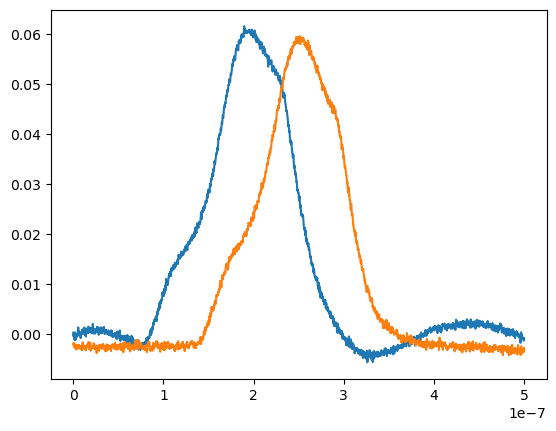

wfm_ict1 size    : 20009
wfm_ict1 max_idx : 7583
wfm_ict2 size    : 20009
wfm_ict2 max_idx : 10045
shift            : 2462


In [6]:
wfm_sig = li_ict1_wfm
wfm_ = pulse_wfm

plt.plot(wfm_sig.tim, wfm_sig.wfm)
plt.plot(wfm_.tim, wfm_.wfm)
plt.show()

shift = wfm_.wfm_idx_max - wfm_sig.wfm_idx_max

print(f'wfm_ict1 size    : {len(wfm_sig.wfm)}')
print(f'wfm_ict1 max_idx : {wfm_sig.wfm_idx_max}')
print(f'wfm_ict2 size    : {len(wfm_.wfm)}')
print(f'wfm_ict2 max_idx : {wfm_.wfm_idx_max}')
print(f'shift            : {shift}')

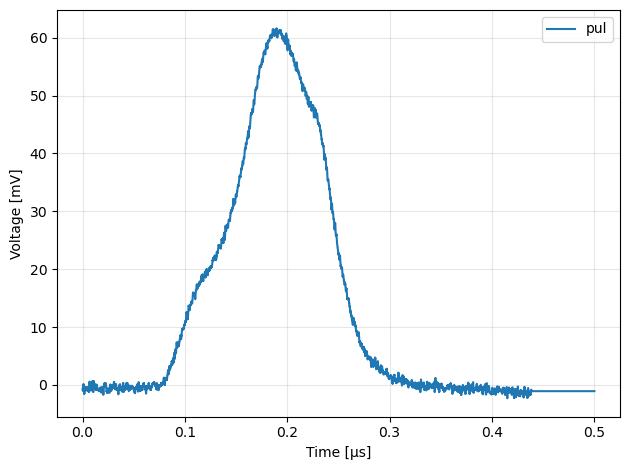

In [7]:
# cria waveform de pulso a partir da waveform do ICT2, deslocada para o time-of-flight da ICT1

wfm_pul = Waveform(wfm_.tim, WaveformUtils.shift_left(wfm_.wfm, shift)) + 0.002
plt.plot(1e6*wfm_pul.tim, 1e3*wfm_pul.wfm, label='pul')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
period = 0.2125e-6
periods = _np.linspace(0.999*period, 1.001*period, 15)
for period in periods:
    coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, period=period, wfm_pul=wfm_pul)
    print(f'period: {1e6*period:.6f} µs, residue: {residues[0]:.8f}')

period: 0.212288 µs, residue: 0.03767383
period: 0.212318 µs, residue: 0.03767356
period: 0.212348 µs, residue: 0.03767334
period: 0.212379 µs, residue: 0.03767316
period: 0.212409 µs, residue: 0.03767303
period: 0.212439 µs, residue: 0.03767293
period: 0.212470 µs, residue: 0.03767288
period: 0.212500 µs, residue: 0.03767288
period: 0.212530 µs, residue: 0.03767291
period: 0.212561 µs, residue: 0.03767299
period: 0.212591 µs, residue: 0.03767312
period: 0.212621 µs, residue: 0.03767328
period: 0.212652 µs, residue: 0.03767349
period: 0.212682 µs, residue: 0.03767374
period: 0.212712 µs, residue: 0.03767403


In [9]:
period = 0.2125e-6
coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, period=period, wfm_pul=wfm_pul)

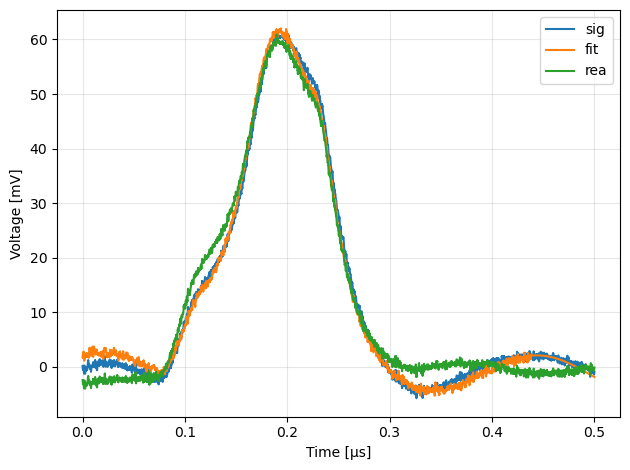

charge sig: 1.238 nC
charge fit: 1.238 nC
charge rea: 1.246 nC


In [10]:
# wfm6 = WfmProcess(wfm1.tim, wfm_fit)

wfm_pul, wfm_uni, wfm_sin, wfm_cos = wfms

wfm_per = coeffs[1] * wfm_uni + coeffs[2] * wfm_sin + coeffs[3] * wfm_cos
wfm_rea = wfm_sig - wfm_per

plt.plot(1e6*wfm_sig.tim, 1e3*wfm_sig.wfm, label='sig')
plt.plot(1e6*wfm_fit.tim, 1e3*wfm_fit.wfm, label='fit')
plt.plot(1e6*wfm_rea.tim, 1e3*wfm_rea.wfm, label='rea')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'charge sig: {1e9*wfm_sig.calc_integral():.3f} nC')
print(f'charge fit: {1e9*wfm_fit.calc_integral():.3f} nC')
print(f'charge rea: {1e9*wfm_rea.calc_integral():.3f} nC')

## Read Online

In [11]:
scope = Scopes.LI_DI_ICT
print(scope)

scopename      : LI_DI_ICT
ipaddr         : 10.128.1.150
hostname       : li-di-ictosc.lnls-sirius.com.br
port           : 5025
channel1       : LI_ICT1
channel2       : LI_ICT2
channel3       : TB_ICT1
channel4       : TB_ICT2
stats_fields   : ('CURR', 'MEAN', 'MIN', 'MAX', 'RANGE', 'STD', 'COUNT')


In [16]:
# pulse only EGUN, nothing else

data = scope.wfm_read(channels=['channel1'])
wfm_pul = Waveform(*data['LI_ICT1'])

In [17]:
# pulse everything else, but without EGUN

data = scope.wfm_read(channels=['channel1'])
wfm_pert = Waveform(*data['LI_ICT1'])

## Create Waveforms

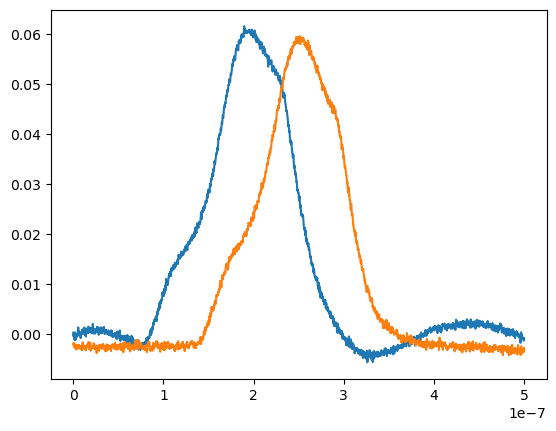

wfm_ict1 size    : 20009
wfm_ict1 max_idx : 7583
wfm_ict2 size    : 20009
wfm_ict2 max_idx : 10045
shift            : 2462


In [12]:
wfm_sig = li_ict1_wfm
wfm_ = pulse_wfm

plt.plot(wfm_sig.tim, wfm_sig.wfm)
plt.plot(wfm_.tim, wfm_.wfm)
plt.show()

shift = wfm_.wfm_idx_max - wfm_sig.wfm_idx_max

print(f'wfm_ict1 size    : {len(wfm_sig.wfm)}')
print(f'wfm_ict1 max_idx : {wfm_sig.wfm_idx_max}')
print(f'wfm_ict2 size    : {len(wfm_.wfm)}')
print(f'wfm_ict2 max_idx : {wfm_.wfm_idx_max}')
print(f'shift            : {shift}')

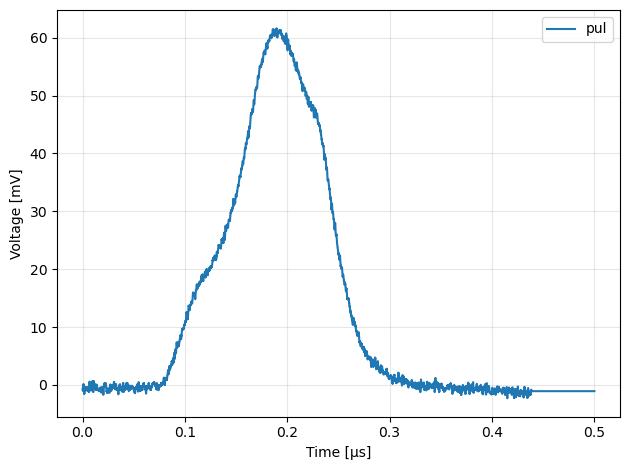

In [13]:
# cria waveform de pulso a partir da waveform do ICT2, deslocada para o time-of-flight da ICT1

wfm_pul = Waveform(wfm_.tim, WaveformUtils.shift_left(wfm_.wfm, shift)) + 0.002
plt.plot(1e6*wfm_pul.tim, 1e3*wfm_pul.wfm, label='pul')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
period = 0.2125e-6
periods = _np.linspace(0.999*period, 1.001*period, 15)
for period in periods:
    coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, wfm_pul, period=period)
    print(f'period: {1e6*period:.6f} µs, residue: {residues[0]:.8f}')

period: 0.212288 µs, residue: 0.03767383
period: 0.212318 µs, residue: 0.03767356
period: 0.212348 µs, residue: 0.03767334
period: 0.212379 µs, residue: 0.03767316
period: 0.212409 µs, residue: 0.03767303
period: 0.212439 µs, residue: 0.03767293
period: 0.212470 µs, residue: 0.03767288
period: 0.212500 µs, residue: 0.03767288
period: 0.212530 µs, residue: 0.03767291
period: 0.212561 µs, residue: 0.03767299
period: 0.212591 µs, residue: 0.03767312
period: 0.212621 µs, residue: 0.03767328
period: 0.212652 µs, residue: 0.03767349
period: 0.212682 µs, residue: 0.03767374
period: 0.212712 µs, residue: 0.03767403


In [7]:
period = 0.2125e-6
coeffs, residues, wfm_fit, wfms = fit_signal(wfm_sig, wfm_pul, period=period)

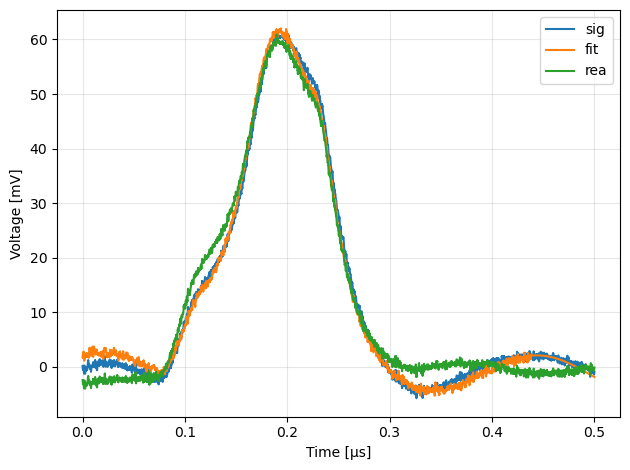

charge sig: 1.238 nC
charge fit: 1.238 nC
charge rea: 1.246 nC


In [8]:
# wfm6 = WfmProcess(wfm1.tim, wfm_fit)

wfm_pul, wfm_uni, wfm_sin, wfm_cos = wfms

wfm_per = coeffs[1] * wfm_uni + coeffs[2] * wfm_sin + coeffs[3] * wfm_cos
wfm_rea = wfm_sig - wfm_per

plt.plot(1e6*wfm_sig.tim, 1e3*wfm_sig.wfm, label='sig')
plt.plot(1e6*wfm_fit.tim, 1e3*wfm_fit.wfm, label='fit')
plt.plot(1e6*wfm_rea.tim, 1e3*wfm_rea.wfm, label='rea')
plt.xlabel('Time [µs]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'charge sig: {1e9*wfm_sig.calc_integral():.3f} nC')
print(f'charge fit: {1e9*wfm_fit.calc_integral():.3f} nC')
print(f'charge rea: {1e9*wfm_rea.calc_integral():.3f} nC')